## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.Load dataset

In [3]:
data = pd.read_csv("C:\\Users\\asus\\Student-marks-prediction\\Students Performance .csv")
data.head()

,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,STUDENT1,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,STUDENT2,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,STUDENT3,19-22,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,STUDENT4,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,STUDENT5,19-22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


## 3. Check Dataset Info

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Student_ID          145 non-null    object
 1   Student_Age         145 non-null    object
 2   Sex                 145 non-null    object
 3   High_School_Type    145 non-null    object
 4   Scholarship         144 non-null    object
 5   Additional_Work     145 non-null    object
 6   Sports_activity     145 non-null    object
 7   Transportation      145 non-null    object
 8   Weekly_Study_Hours  145 non-null    int64 
 9   Attendance          145 non-null    object
 10  Reading             145 non-null    object
 11  Notes               145 non-null    object
 12  Listening_in_Class  145 non-null    object
 13  Project_work        145 non-null    object
 14  Grade               145 non-null    object
dtypes: int64(1), object(14)
memory usage: 17.1+ KB
None


## 4. Check Missing Values

In [5]:
print(data.isnull().sum())

Student_ID            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64


## 5. Check Grade Distribution

In [6]:
print(data["Grade"].value_counts())

Grade
AA      35
BA      24
BB      21
CC      17
DD      17
DC      13
CB      10
Fail     8
Name: count, dtype: int64


## 6. Visualize Grades

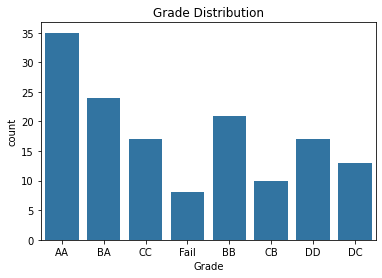

In [7]:
sns.countplot(x="Grade", data=data)
plt.title("Grade Distribution")
plt.show()

## 7. Remove Student_ID

In [8]:
data = data.drop("Student_ID", axis=1)
data.head()

,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,19-22,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,19-22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


## 8. Convert Text Data to Numbers

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for column in data.columns:
    data[column] = encoder.fit_transform(data[column])

## 9. Check Converted Data

In [10]:
data.head()

,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,1,1,0,2,1,0,1,0,1,1,2,1,0,0
1,1,1,0,2,1,0,1,0,1,1,1,2,1,0
2,1,1,2,2,0,0,1,1,2,0,1,1,1,0
3,0,0,1,2,1,0,0,1,1,0,2,1,0,0
4,1,1,1,2,0,0,0,3,1,1,1,2,1,0


## 10. Split Input and Output

In [11]:
X = data.drop("Grade", axis=1)
y = data["Grade"]

## 11. Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 12. Train Model

In [16]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

## 13. Predict

In [17]:
y_pred = model.predict(X_test)

## 14. Check Accuracy

In [18]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.2413793103448276


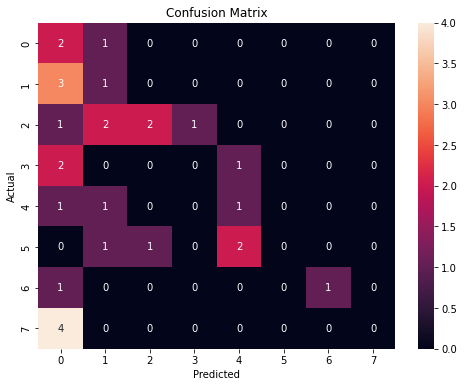

In [21]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 15. Save Model

In [22]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))